<a href="https://colab.research.google.com/github/gilIolgenblum/CrowdingModeWorkshop/blob/main/tutorials/03_parameter_sensitivity_and_interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parameter Sensitivity and Interpretation

## Goal
In this tutorial, you will explore how the physical parameters in the Flory-Huggins thermodynamic framework govern protein stability.
We will visually inspect the effect of altering:
1. **Protein SASA** (Solvent Accessible Surface Area)
2. **Cosolute $\chi$** (Flory-Huggins non-ideal interaction)

## Setup
We import the package and `matplotlib.pyplot`.

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/CrowdingModeWorkshop.git
    # Change the working directory to the repository root
    os.chdir('/content/CrowdingModeWorkshop')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/CrowdingModeWorkshop/src')

In [2]:
import crowding as cr
import matplotlib.pyplot as plt
import numpy as np

print(f"Module imported successfully: {cr.__name__}")

Module imported successfully: crowding


## Effect of Protein SASA
The Solvent Accessible Surface Area (SASA) defines how much of the protein is exposed to the solvent and crowder.
Let's see what happens when we increase the SASA for the same cosolute.

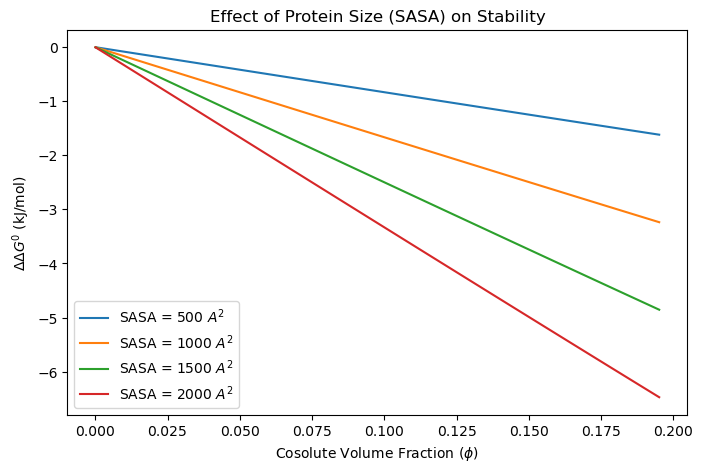

In [3]:
# Define a standard cosolute
cosolute = cr.Cosolute(nu=2.0, chi=0.5, chiTS=0.0)

sasa_values = [500, 1000, 1500, 2000]

fig, ax = plt.subplots(figsize=(8, 5))

for sasa in sasa_values:
    # Create the model with varying SASA
    protein = cr.Protein(SASA=sasa)
    model = cr.CrowdingModel(
        protein=protein,
        cosolute=cosolute,
        eps=0.0,
        epsTS=0.0,
        phiC_max=0.2,
        dphiC=0.005,
        T=298.15
    )

    # Solve
    model.solve_equil()

    # Plot
    ax.plot(model.phiC, model.ddA_kj, label=f"SASA = {sasa} $A^2$")

ax.set_xlabel(r"Cosolute Volume Fraction ($\phi$)")
ax.set_ylabel(r"$\Delta\Delta G^0$ (kJ/mol)")
ax.set_title("Effect of Protein Size (SASA) on Stability")
ax.legend()
plt.show()

### Interpretation of SASA
- The magnitude of the crowding effect scales linearly with the SASA of the protein.
- A larger protein (or a larger difference in SASA between the folded and unfolded states) will experience a much stronger thermodynamic push from the crowders.

## Effect of Excluded Volume ($\nu$) on $\Delta\Delta G^0$ $\Delta\Delta H^0$ and $T\Delta\Delta S^0$
The parameter $\nu$ represents the excluded volume of the cosolute. In principle, changing the excluded volume should affect only the entropy ($T\Delta\Delta S^0$) but have absolutely no effect on the enthalpy ($\Delta\Delta H^0$):

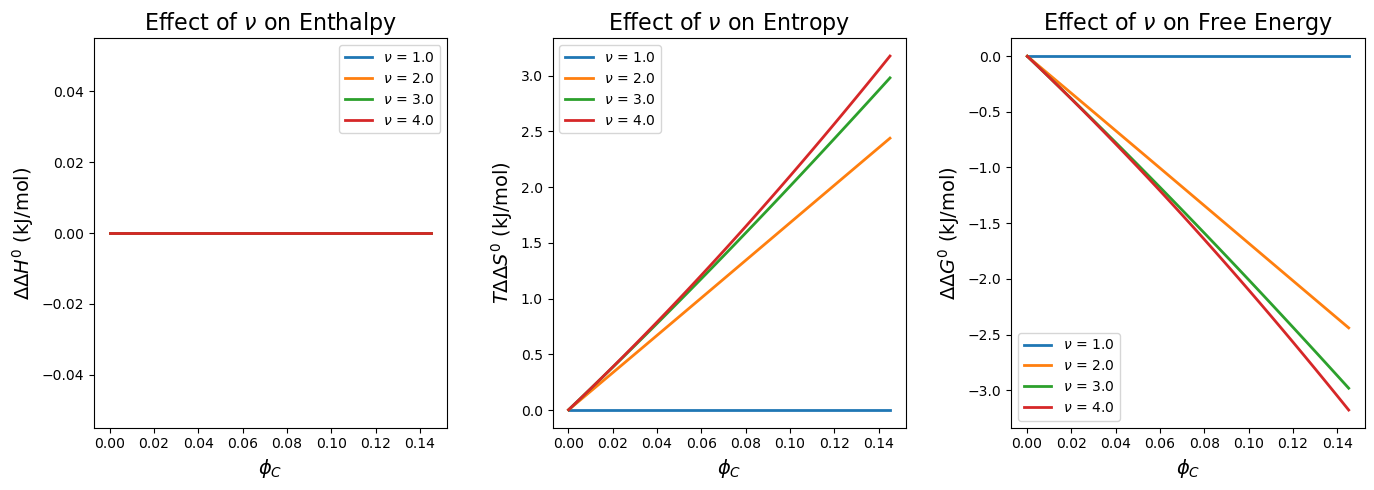

In [4]:
protein = cr.Protein(SASA=1000.0)
nu_values = [1.0, 2.0, 3.0, 4.0]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for nu_val in nu_values:
    cosolute = cr.Cosolute(nu=nu_val, chi=0.0, chiTS=0.0)
    model = cr.CrowdingModel(
        protein=protein, cosolute=cosolute,
        eps=0.0, epsTS=0.0,
        phiC_max=0.15, dphiC=0.005, T=298.15
    )
    model.solve_equil()
    axes[0].plot(model.phiC, model.ddE_kj, lw=2, label=rf'$\nu$ = {nu_val}')
    axes[1].plot(model.phiC, model.TddS_kj, lw=2, label=rf'$\nu$ = {nu_val}')
    axes[2].plot(model.phiC, model.ddA_kj, lw=2, label=rf'$\nu$ = {nu_val}')

axes[0].set_xlabel(r'$\phi_C$', fontsize=14)
axes[0].set_ylabel(r'$\Delta\Delta H^0$ (kJ/mol)', fontsize=14)
axes[0].set_title(r'Effect of $\nu$ on Enthalpy', fontsize=16)
axes[0].legend()

axes[1].set_xlabel(r'$\phi_C$', fontsize=14)
axes[1].set_ylabel(r'$T\Delta\Delta S^0$ (kJ/mol)', fontsize=14)
axes[1].set_title(r'Effect of $\nu$ on Entropy', fontsize=16)
axes[1].legend()

axes[2].set_xlabel(r'$\phi_C$', fontsize=14)
axes[2].set_ylabel(r'$\Delta\Delta G^0$ (kJ/mol)', fontsize=14)
axes[2].set_title(r'Effect of $\nu$ on Free Energy', fontsize=16)
axes[2].legend()

plt.tight_layout()
plt.show()

However, when $\chi \neq 0$, changing $\nu$ can also affect $\Delta\Delta H^0$. Check this for yourself!

Can you explain why this happens?

<!--
Although $\nu$ does not directly contribute to the energetic terms, changing $\nu$ shifts the equilibrium distribution of cosolute between the protein domain and the bulk solution. Specifically, increasing $\nu$ enhances cosolute exclusion from the protein domain, increasing the fraction of cosolute molecules in the bulk where they interact with the solvent. Therefore, when the enthalpic interaction parameter $\chi_H = \chi + \chi_{TS} \neq 0$, changing $\nu$ indirectly affects the folding enthalpy, $\Delta\Delta H^0$.
-->

### Interpretation of $\nu$
As $\nu$ increases, the larger excluded volume of the cosolute exerts a stronger steric effect on the protein, driving $\Delta\Delta G^0$ to more negative values and thereby stabilizing the compact folded state. This free-energy gain is entropic in origin, as excluded-volume interactions are purely steric and do not involve cosolute-cosolute interactions.


## Effect of Flory-Huggins $\chi$
The $\chi$ parameter represents the non-ideal interaction between the cosolute and the solvent (water).
- $\chi < 0$: unlike interactions are favorable, strong mixing.
- $\chi \sim 0$: ideal mixing.
- $\chi > 0$: unlike contacts are unfavorable.
- $\chi > \chi_c$: a two-phase region becomes possible.

The critical Flory–Huggins parameter is:
$$
\chi_c=\frac{1}{2}\left( 1+ \frac{1}{\sqrt\nu} \right)^2
$$
and the criticla composition is:
$$
\phi = \frac{\sqrt\nu}{1+\sqrt\nu}
$$
- what is the upper limit of $\chi$ for $\nu=2$? (small cosolute like urea)
- what is the upper limit of $\chi$ for $\nu\gg1$? (large polymer)

In [5]:
# helper function
def spinodal_phi(nu, chi):
    if chi<0:
        return np.nan, np.nan
    term = 2*chi+1-1/nu
    try:
        with np.errstate(divide='ignore', invalid='ignore'):
            phi_spm, phi_spp = (term-np.sqrt(term**2-8*chi))/(4*chi), (term+np.sqrt(term**2-8*chi))/(4*chi)
        return  (phi_spm, phi_spp) if phi_spm>0 and phi_spp<1 else (np.nan, np.nan)
    except Exception:
        return np.nan, np.nan

def critical_phi(nu, chi):
    return np.sqrt(nu)/(1+np.sqrt(nu))

def mask_critical(phi,phi_sp):
    if not isinstance(phi_sp[0], np.float64):
        return np.zeros(len(phi), dtype=bool)
    return (phi > phi_sp[0]) & (phi < phi_sp[1])

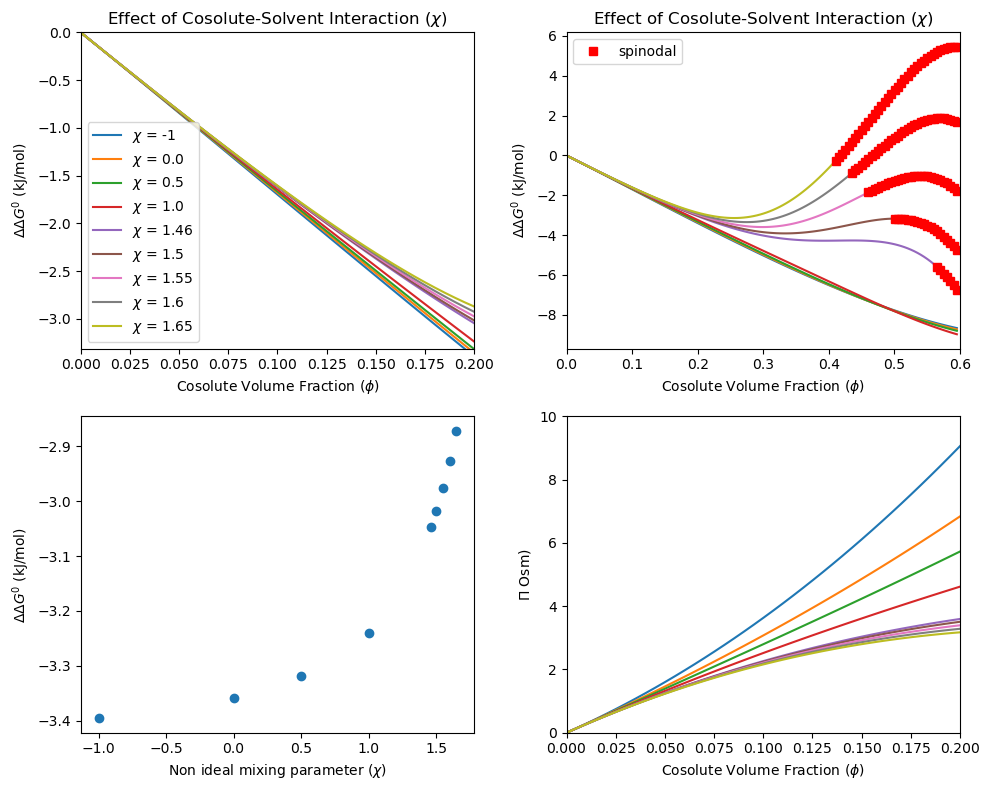

In [6]:
protein = cr.Protein(SASA=1000.0)

chi_values = [-1,0.0, 0.5, 1.0, 1.46, 1.5, 1.55, 1.6, 1.65]

fig, ax = plt.subplots(2,2, figsize=(10, 8))

ymin, ymax= 0, 0
xlim=[(0,0.2),
    (0,0.6),
    (None, None)]

ddG_at_0p2 = []

nu_val = 2.0

for chi_val in chi_values:
    # Create the model with varying chi
    cosolute = cr.Cosolute(nu=nu_val, chi=chi_val, chiTS=0.0)

    model = cr.CrowdingModel(
        protein=protein,
        cosolute=cosolute,
        eps=0.0,
        epsTS=0.0,
        phiC_max=xlim[1][1],
        dphiC=0.005,
        T=298.15
    )

    # Solve
    model.solve_equil()
    ddG_at_0p2.append(model.ddA_kj[np.isclose(model.phiC, 0.2, rtol=0.001)])

    # Plot curves
    ax[0,0].plot(model.phiC, model.ddA_kj, label=r"$\chi$ = {}".format(chi_val))
    ax[0,1].plot(model.phiC, model.ddA_kj, label=r"$\chi$ = {}".format(chi_val))
    ax[1,1].plot(model.phiC, model.osm,    label=r"$\chi$ = {}".format(chi_val))

    phi_sp = spinodal_phi(nu_val,chi_val)
    mask = mask_critical(model.phiC,phi_sp)
    handel=ax[0,1].plot(model.phiC[mask], model.ddA_kj[mask],'sr',label=None)
    

    # limit x and y ranges for left panel
    bottom = model.ddA_kj[model.phiC<xlim[0][1]].min()
    top = model.ddA_kj[model.phiC<=xlim[0][1]].min()
    ymin = bottom if bottom < ymin else ymin
    ymax =  top if top > ymax else ymax

# plot free energy values at phi=0.2
ax[1,0].plot(chi_values, ddG_at_0p2, 'o')



for i in range(2):
    ax[0,i].set_xlabel(r"Cosolute Volume Fraction ($\phi$)")
    ax[0, i].set_ylabel(r"$\Delta\Delta G^0$ (kJ/mol)")
    ax[0, i].set_title(r"Effect of Cosolute-Solvent Interaction ($\chi$)")
    ax[0, i].set_xlim(xlim[i])
ax[0,0].legend()
ax[0,0].set_ylim((ymin,ymax))
ax[0,1].legend(handel,['spinodal'])
ax[1,0].set_xlabel(r"Non ideal mixing parameter ($\chi$)")
ax[1,0].set_ylabel(r"$\Delta\Delta G^0$ (kJ/mol)")
ax[1,1].set_ylabel(r"$\Pi$ Osm)")
ax[1,1].set_xlabel(r"Cosolute Volume Fraction ($\phi$)")
ax[1,1].set_xlim((0, 0.2))
ax[1,1].set_ylim((0, 10))

plt.tight_layout()
plt.show()

### Interpretation of $\chi$
- As $\chi$ decreases, the cosolute effectively "squeezes" the protein more strongly (larger osmotic pressure, due to favorable interactions with water), driving a more negative $\Delta\Delta G^0$ (stabilization of the compact folded state).


## Effect of Soft Interaction Energy ($\varepsilon$) on $\Delta\Delta G^0$
The parameter $\epsilon$ represents the soft interaction energy between the cosolute and the protein surface. Positive values mean the cosolute is repelled from the surface, while negative values mean the cosolute is attracted to the surface.

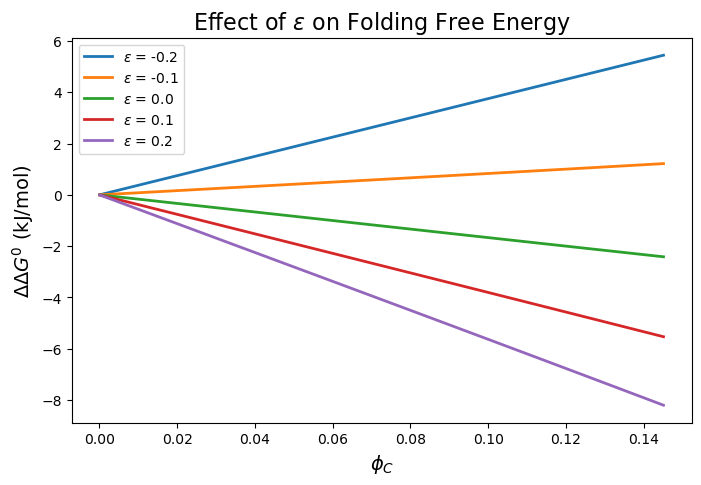

In [7]:
protein = cr.Protein(SASA=1000.0)
cosolute = cr.Cosolute(nu=2.0, chi=0.5, chiTS=0.0)
eps_values = [-0.2, -0.1, 0.0, 0.1, 0.2]

fig, ax = plt.subplots(figsize=(8, 5))

for eps_val in eps_values:
    model = cr.CrowdingModel(
        protein=protein, cosolute=cosolute,
        eps=eps_val, epsTS=0.0,
        phiC_max=0.15, dphiC=0.005, T=298.15
    )
    model.solve_equil()
    ax.plot(model.phiC, model.ddA_kj, lw=2, label=r'$\varepsilon$ = {}'.format(eps_val))

ax.set_xlabel(r'$\phi_C$', fontsize=14)
ax.set_ylabel(r'$\Delta\Delta G^0$ (kJ/mol)', fontsize=14)
ax.set_title(r'Effect of $\varepsilon$ on Folding Free Energy', fontsize=16)
ax.legend()
plt.show()

### Interpretation of $\varepsilon$
- $\varepsilon>0$ means cosolute-protein repulsions. These repulsion further stabilize the protein naive state, as if the cosolute excluded volume is enhanced by the soft repulsions.
- $\varepsilon<0$ means cosolute-protein attractions. These attractions destabilize the protein naive state, as if the cosolute excluded volume is reduced by the soft repulsions. Also, cosolute that stick to a protein moiety lead to surface exposure, i.e., unfolding.


## Effect of $\chi_{TS}$ on $\Delta\Delta H^0$ and $T\Delta\Delta S^0$
The parameter $\chi_{TS}$ represents the entropic component of the Flory-Huggins interaction parameter $\chi=\chi_H-\chi_{TS}$. Modifying it alters the balance between enthalpy and entropy for the non-ideal mixing term.

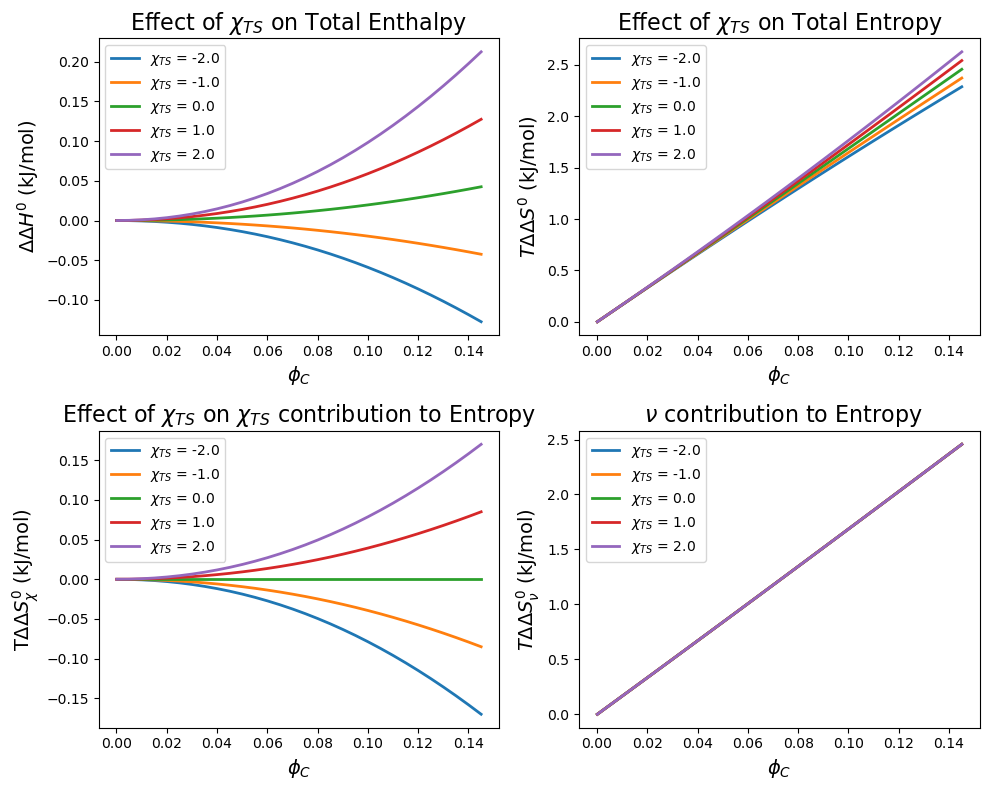

In [8]:
protein = cr.Protein(SASA=1000.0)
chiTS_values = [-2.0, -1.0, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for chiTS_val in chiTS_values:
    # Keeping total chi constant, modifying chiTS
    cosolute = cr.Cosolute(nu=2.0, chi=0.5, chiTS=chiTS_val)
    model = cr.CrowdingModel(
        protein=protein, cosolute=cosolute,
        eps=0.0, epsTS=0.0,
        phiC_max=0.15, dphiC=0.005, T=298.15
    )
    model.solve_equil()
    axes[0,0].plot(model.phiC, model.ddE_kj, lw=2, label=rf'$\chi_{{TS}}$ = {chiTS_val}')
    axes[0,1].plot(model.phiC, model.TddS_kj, lw=2, label=rf'$\chi_{{TS}}$ = {chiTS_val}')
    axes[1,0].plot(model.phiC, model.TddS_chi_kj, lw=2, label=rf'$\chi_{{TS}}$ = {chiTS_val}')
    axes[1,1].plot(model.phiC, model.TddS_nu_kj, lw=2, label=rf'$\chi_{{TS}}$ = {chiTS_val}')

axes[0,0].set_xlabel(r'$\phi_C$', fontsize=14)
axes[0,0].set_ylabel(r'$\Delta\Delta H^0$ (kJ/mol)', fontsize=14)
axes[0,0].set_title(r'Effect of $\chi_{TS}$ on Total Enthalpy', fontsize=16)
axes[0,0].legend()

axes[0,1].set_xlabel(r'$\phi_C$', fontsize=14)
axes[0,1].set_ylabel(r'$T\Delta\Delta S^0$ (kJ/mol)', fontsize=14)
axes[0,1].set_title(r'Effect of $\chi_{TS}$ on Total Entropy', fontsize=16)
axes[0,1].legend()

axes[1,0].set_xlabel(r'$\phi_C$', fontsize=14)
axes[1,0].set_ylabel(r'T$\Delta\Delta S^0_{\chi}$ (kJ/mol)', fontsize=14)
axes[1,0].set_title(r'Effect of $\chi_{TS}$ on $\chi_{TS}$ contribution to Entropy', fontsize=16)
axes[1,0].legend()

axes[1,1].set_xlabel(r'$\phi_C$', fontsize=14)
axes[1,1].set_ylabel(r'$T\Delta\Delta S^0_\nu$ (kJ/mol)', fontsize=14)
axes[1,1].set_title(r' $\nu$ contribution to Entropy', fontsize=16)
axes[1,1].legend()

plt.tight_layout()
plt.show()

## Interpretation of $\chi_{TS}$

As $\chi_{TS}$ increases while $\chi$ remains constant, $\chi_H$ decreases and becomes more negative. Consequently:

- $\Delta\Delta H^0$, which is determined entirely by $\Delta\Delta H^0_\chi$ because $\Delta\Delta H^0_\nu = 0$, becomes more positive, corresponding to enthalpic destabilization.
- $T\Delta\Delta S^0_\chi$ becomes more positive, corresponding to entropic stabilization.
- Because $\chi$ remains constant, the changes in $\Delta\Delta H^0_\chi$ and $T\Delta\Delta S^0_\chi$ compensate each other, leaving the free-energy contribution associated with $\chi$ unchanged.
- The total $T\Delta\Delta S^0$ is therefore dominated by the contribution from $\nu$.

## Effect of Soft Interaction Entropy ($\varepsilon_{TS}$) on $\Delta\Delta H^0$ and $T\Delta\Delta S^0$
The parameter $\varepsilon_{TS}$ is the entropic component of the soft interaction $\varepsilon=\varepsilon_H-\varepsilon_{TS}$. Similar to $\chi_{TS}$, it splits the total free energy contribution of the soft interaction into enthalpic and entropic components.

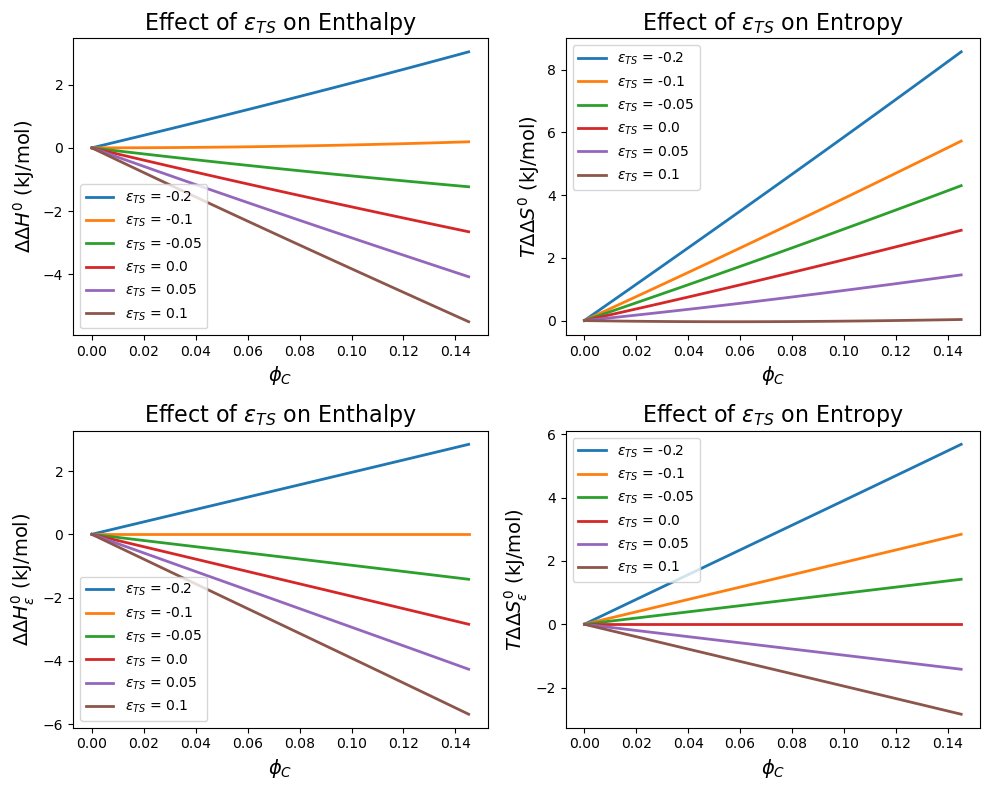

In [9]:
protein = cr.Protein(SASA=1000.0)
cosolute = cr.Cosolute(nu=2.0, chi=0.5, chiTS=0.0)
epsTS_values = [-0.2, -0.1, -0.05, 0.0, 0.05, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for epsTS_val in epsTS_values:
    model = cr.CrowdingModel(
        protein=protein, cosolute=cosolute,
        eps=0.1, epsTS=epsTS_val, # Keeping eps fixed, varying epsTS
        phiC_max=0.15, dphiC=0.005, T=298.15
    )
    model.solve_equil()
    axes[0,0].plot(model.phiC, model.ddE_kj, lw=2, label=rf'$\varepsilon_{{TS}}$ = {epsTS_val}')
    axes[0,1].plot(model.phiC, model.TddS_kj, lw=2, label=rf'$\varepsilon_{{TS}}$ = {epsTS_val}')
    axes[1,0].plot(model.phiC, model.ddE_eps_kj, lw=2, label=rf'$\varepsilon_{{TS}}$ = {epsTS_val}')
    axes[1,1].plot(model.phiC, model.TddS_eps_kj, lw=2, label=rf'$\varepsilon_{{TS}}$ = {epsTS_val}')

axes[0,0].set_xlabel(r'$\phi_C$', fontsize=14)
axes[0,0].set_ylabel(r'$\Delta\Delta H^0$ (kJ/mol)', fontsize=14)
axes[0,0].set_title(r'Effect of $\varepsilon_{TS}$ on Enthalpy', fontsize=16)
axes[0,0].legend()

axes[0,1].set_xlabel(r'$\phi_C$', fontsize=14)
axes[0,1].set_ylabel(r'$T\Delta\Delta S^0$ (kJ/mol)', fontsize=14)
axes[0,1].set_title(r'Effect of $\varepsilon_{TS}$ on Entropy', fontsize=16)
axes[0,1].legend()

axes[1,0].set_xlabel(r'$\phi_C$', fontsize=14)
axes[1,0].set_ylabel(r'$\Delta\Delta H^0_\varepsilon$ (kJ/mol)', fontsize=14)
axes[1,0].set_title(r'Effect of $\varepsilon_{TS}$ on Enthalpy', fontsize=16)
axes[1,0].legend()

axes[1,1].set_xlabel(r'$\phi_C$', fontsize=14)
axes[1,1].set_ylabel(r'$T\Delta\Delta S^0_\varepsilon$ (kJ/mol)', fontsize=14)
axes[1,1].set_title(r'Effect of $\varepsilon_{TS}$ on Entropy', fontsize=16)
axes[1,1].legend()

plt.tight_layout()
plt.show()

### Interpretation of $\varepsilon_{TS}$
- $\Delta\Delta H^0_\varepsilon$ can easily dominate $\Delta\Delta H^0$, and $T\Delta\Delta S^0_\varepsilon$ can easily dominate $T\Delta\Delta S^0$.
- As $\varepsilon_{TS}$ increases and $\varepsilon_H$ decreases, $\Delta\Delta H^0$ becomes more negative (more stabilziing enthalpically) and  $T\Delta\Delta S^0$ less positive (less stabilizing entropically).